# Hand Gesture Recognition

In [6]:
import numpy as np
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from scipy.fft import fft, fftfreq

In [7]:
from enum import IntEnum


base_dir = '../recordings/'
num_classes = 7
class Classes(IntEnum):
    NEUTRAL = 0,
    FIST = 1,
    INDEX = 2,
    MIDDLE = 3,
    OK = 4,
    PEACE = 5,
    THUMB = 6
    
# structure: recordings/date/data/*.csv
files = [[] for _ in range(num_classes)]

for date_dir, _, filenames in os.walk(base_dir):
    if date_dir.endswith('data'):
        for filename in filenames:
            if filename.startswith('fft'):
                continue
            if filename.find('neutral') != -1:
                files[Classes.NEUTRAL].append(os.path.join(date_dir, filename))
            elif filename.find('fist') != -1:
                files[Classes.FIST].append(os.path.join(date_dir, filename))
            elif filename.find('index') != -1:
                files[Classes.INDEX].append(os.path.join(date_dir, filename))
            elif filename.find('middle') != -1:
                files[Classes.MIDDLE].append(os.path.join(date_dir, filename))
            elif filename.find('ok') != -1:
                files[Classes.OK].append(os.path.join(date_dir, filename))
            elif filename.find('peace') != -1:
                files[Classes.PEACE].append(os.path.join(date_dir, filename))
            elif filename.find('thumb') != -1:
                files[Classes.THUMB].append(os.path.join(date_dir, filename))

print(files)      

[['../recordings/02_12_24/data/gilbert_neutral_0.csv', '../recordings/05_12_24/data/luka_neutral_0.csv', '../recordings/05_12_24/data/teacher_neutral_0.csv', '../recordings/01_12_24_initial_placement_test/data/gilbert_neutral_0.csv', '../recordings/01_12_24_initial_placement_test/data/nad_neutral_0.csv'], ['../recordings/02_12_24/data/gilbert_fist_0.csv', '../recordings/05_12_24/data/teacher_fist_0.csv', '../recordings/05_12_24/data/luka_fist_0.csv', '../recordings/01_12_24_initial_placement_test/data/gilbert_fist_0.csv', '../recordings/01_12_24_initial_placement_test/data/nad_fist_0.csv'], ['../recordings/02_12_24/data/gilbert_index_0.csv', '../recordings/05_12_24/data/luka_index_0.csv', '../recordings/05_12_24/data/teacher_index_0.csv', '../recordings/01_12_24_initial_placement_test/data/gilbert_index_0.csv', '../recordings/01_12_24_initial_placement_test/data/nad_index_0.csv'], ['../recordings/05_12_24/data/luka_middle_0.csv', '../recordings/05_12_24/data/teacher_middle_0.csv', '../

Our initial static gesture recording includes 7 classes: neutral, fist, index finger, middle finger, ok, peace, thumb.

In [17]:
neutral_df = [pd.read_csv(file, header=None) for file in files[Classes.NEUTRAL]]
fist_df = [pd.read_csv(file, header=None) for file in files[Classes.FIST]]
index_df = [pd.read_csv(file, header=None) for file in files[Classes.INDEX]]
middle_df = [pd.read_csv(file, header=None) for file in files[Classes.MIDDLE]]
ok_df = [pd.read_csv(file, header=None) for file in files[Classes.OK]]
peace_df = [pd.read_csv(file, header=None) for file in files[Classes.PEACE]]
thumb_df = [pd.read_csv(file, header=None) for file in files[Classes.THUMB]]

In [19]:
for df in neutral_df:
    df.drop_duplicates(inplace=True)
    df['class'] = Classes.NEUTRAL
for df in fist_df:
    df.drop_duplicates(inplace=True)
    df['class'] = Classes.FIST
for df in index_df:
    df.drop_duplicates(inplace=True)
    df['class'] = Classes.INDEX
for df in middle_df:
    df.drop_duplicates(inplace=True)
    df['class'] = Classes.MIDDLE
for df in ok_df:
    df.drop_duplicates(inplace=True)
    df['class'] = Classes.OK
for df in peace_df:
    df.drop_duplicates(inplace=True)
    df['class'] = Classes.PEACE
for df in thumb_df:
    df.drop_duplicates(inplace=True)
    df['class'] = Classes.THUMB

In [6]:
def get_min_df_len(dfs):
    min_len = min([len(df_) for df in dfs for df_ in df])
    return min_len

min_len = get_min_df_len([neutral_df, fist_df, index_df, middle_df, ok_df, peace_df, thumb_df])
print(min_len)

3290


Optional subsampling:

In [7]:
num_samples = min_len

neutral_df = pd.concat([df.sample(num_samples) for df in neutral_df])
fist_df = pd.concat([df.sample(num_samples) for df in fist_df])
index_df = pd.concat([df.sample(num_samples) for df in index_df])
middle_df = pd.concat([df.sample(num_samples) for df in middle_df])
ok_df = pd.concat([df.sample(num_samples) for df in ok_df])
peace_df = pd.concat([df.sample(num_samples) for df in peace_df])
thumb_df = pd.concat([df.sample(num_samples) for df in thumb_df])
# neutral_df = neutral_df[0].sample(num_samples)
# fist_df = fist_df[0].sample(num_samples)
# index_df = index_df[0].sample(num_samples)
# middle_df = middle_df[0].sample(num_samples)
# ok_df = ok_df[0].sample(num_samples)
# peace_df = peace_df[0].sample(num_samples)
# thumb_df = thumb_df[0].sample(num_samples)

In [8]:
len(neutral_df), len(fist_df), len(index_df), len(middle_df), len(ok_df), len(peace_df), len(thumb_df)

(16450, 16450, 16450, 13160, 13160, 13160, 13160)

In [9]:
neutral_df.head()

,0,1,2,3,4,5,6,7,8,9,...,23,24,25,26,27,28,29,30,31,class
2431,17490,17480,17479,17480,17495,17492,17489,17463,18308,18306,...,17781,18675,18643,18609,18584,18575,18591,18601,18604,0
6,17313,17323,17319,17328,17322,17315,17337,17357,18358,18344,...,17530,18127,18164,18179,18046,18039,18026,18057,18070,0
933,18397,18412,18435,18436,18430,18462,18495,18500,17627,17636,...,17508,17487,17447,17478,17509,17507,17519,17458,17457,0
3019,18190,18142,18174,18236,18239,18209,18180,18149,17635,17619,...,17657,17696,17662,17636,17610,17618,17640,17655,17659,0
2198,18806,18812,18830,18817,18797,18772,18798,18818,17758,17741,...,18441,17519,17474,17407,17393,17416,17419,17406,17432,0


In [10]:
fist_df.head()

,0,1,2,3,4,5,6,7,8,9,...,23,24,25,26,27,28,29,30,31,class
1333,17680,18233,18759,19148,18718,18616,18536,18839,17503,17619,...,18674,17464,17733,17630,17628,17505,17284,17492,17634,1
9439,17360,17349,17332,17320,17315,17309,17303,17294,18307,18320,...,18281,18207,18207,18195,18203,18225,18182,18200,18213,1
1592,17744,17735,17631,17586,17811,17775,17674,17572,18477,18534,...,18682,18276,18514,18626,18507,18407,18441,18451,18397,1
13784,17760,17784,17867,17938,17874,17866,17965,17938,18478,18457,...,18586,18490,18447,18544,18519,18520,18499,18540,18556,1
2946,17480,17471,17465,17458,17464,17462,17478,17484,17478,17444,...,17689,18296,18306,18322,18368,18386,18389,18373,18343,1


Combine dataframes

In [11]:
df = pd.concat([neutral_df, fist_df, index_df, middle_df, ok_df, peace_df, thumb_df], ignore_index=True)

print(df.head())
print(df.iloc[:, -1].value_counts())

       0      1      2      3      4      5      6      7      8      9  ...  \
0  17490  17480  17479  17480  17495  17492  17489  17463  18308  18306  ...   
1  17313  17323  17319  17328  17322  17315  17337  17357  18358  18344  ...   
2  18397  18412  18435  18436  18430  18462  18495  18500  17627  17636  ...   
3  18190  18142  18174  18236  18239  18209  18180  18149  17635  17619  ...   
4  18806  18812  18830  18817  18797  18772  18798  18818  17758  17741  ...   

      23     24     25     26     27     28     29     30     31  class  
0  17781  18675  18643  18609  18584  18575  18591  18601  18604      0  
1  17530  18127  18164  18179  18046  18039  18026  18057  18070      0  
2  17508  17487  17447  17478  17509  17507  17519  17458  17457      0  
3  17657  17696  17662  17636  17610  17618  17640  17655  17659      0  
4  18441  17519  17474  17407  17393  17416  17419  17406  17432      0  

[5 rows x 33 columns]
class
0    16450
1    16450
2    16450
3    13160
4 

In [12]:
sensor_data = df.iloc[:, :-1]
labels = df.iloc[:, -1]

# Data visualization

## Sensor signals

In [ ]:
from scipy import signal
from scipy.signal import butter
from numpy import mean, std

lf = 20
hf = 400
fs = 1150
trim = 4*8*5
bandpass_order = 4
outlier_rejection_stds = 6

plot_all_timeline = False
num_sensors = 4

def plot_time_signals(dataframe, row_index, title):
    row_data = dataframe.iloc[row_index, :-1]

    # Split the row into 8 groups corresponding to sensors
    signals = np.array_split(row_data.values, num_sensors)

    # Plot each sensor's signal
    plt.figure(figsize=(12, 6))
    for i, signal in enumerate(signals):
        plt.plot(signal, label=f'Sensor {i + 1}')
    
    plt.title(f"{title} (Row {row_index})")
    plt.xlabel("Time Steps")
    plt.ylabel("Signal Amplitude")
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_all_time_signals(dataframe, title):    
    all_row_data = dataframe.iloc[:, :-1]
    # Plot each sensor's signal
    signals = np.array_split(all_row_data.values, num_sensors)
    fig, axs = plt.subplots(2, 2, figsize=(24, 16))
    axs = axs.flatten()
    for sensor in range(0, num_sensors):
        sigs = signals[sensor]
        sigs = np.array(sigs).flatten()
        axs[sensor].set_title(f'Sensor {sensor + 1}')
        axs[sensor].plot(sigs)
    fig.suptitle(title)
    
    plt.show()


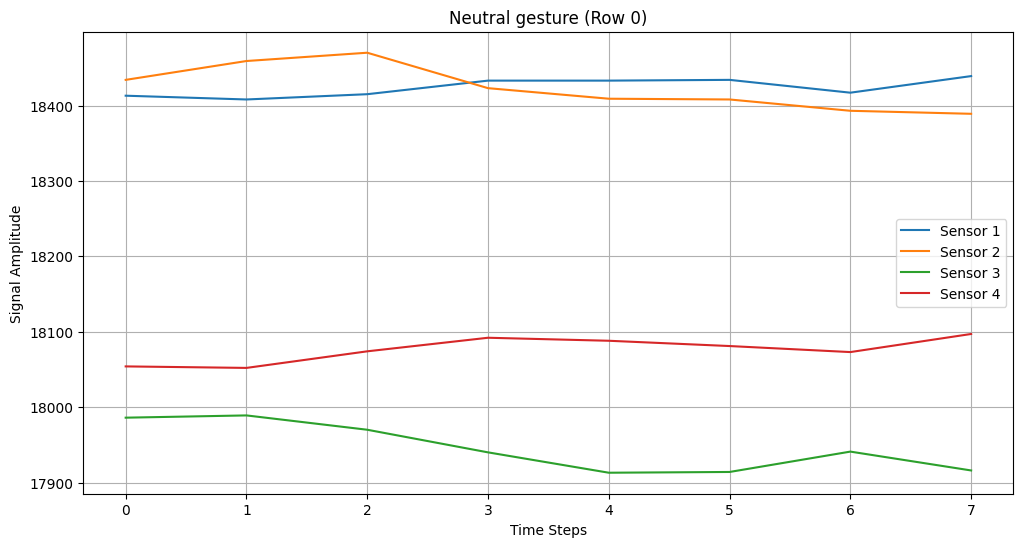

In [19]:
plot_time_signals(neutral_df, row_index=0, title='Neutral gesture')

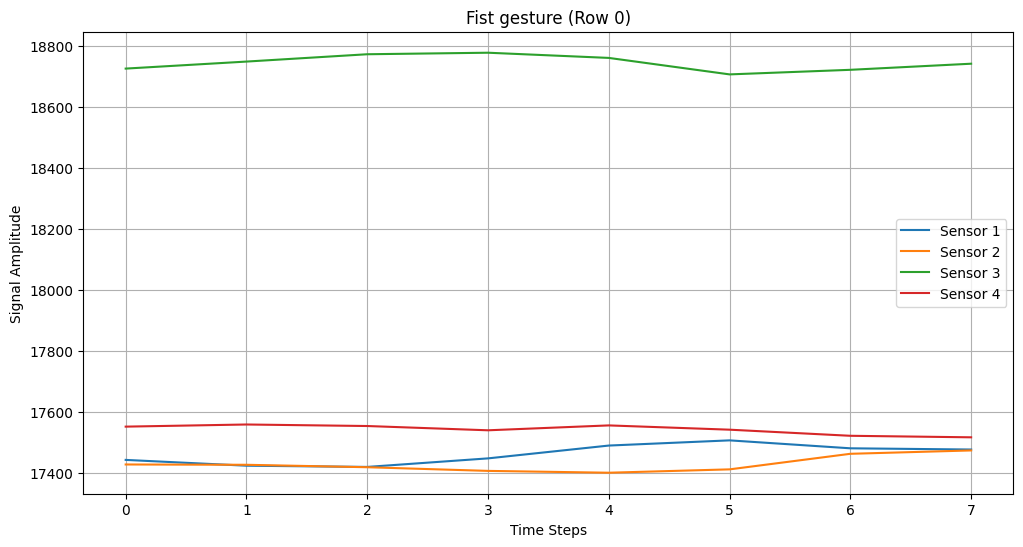

In [20]:
plot_time_signals(fist_df, row_index=0, title='Fist gesture')

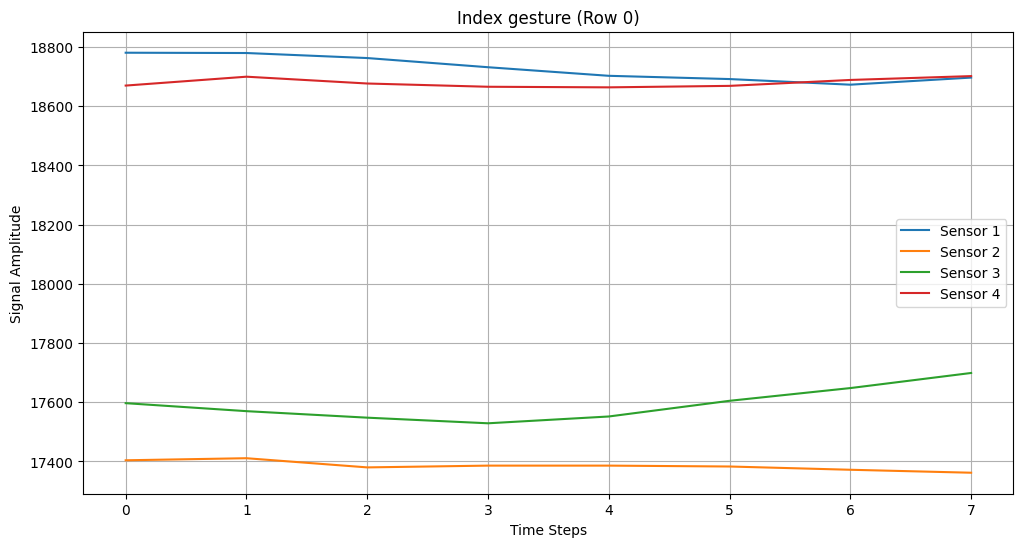

In [21]:
plot_time_signals(index_df, row_index=0, title='Index gesture')

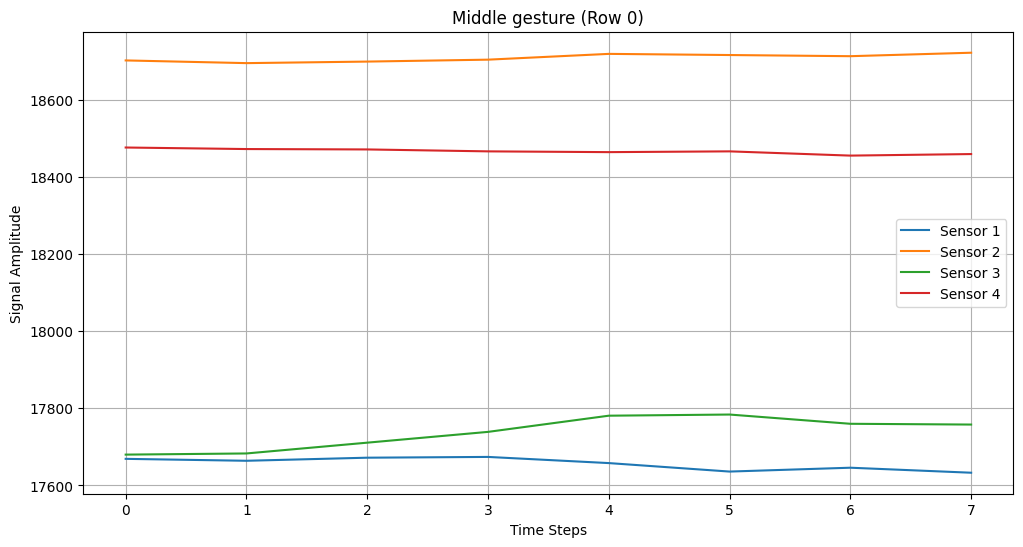

In [22]:
plot_time_signals(middle_df, row_index=0, title='Middle gesture')

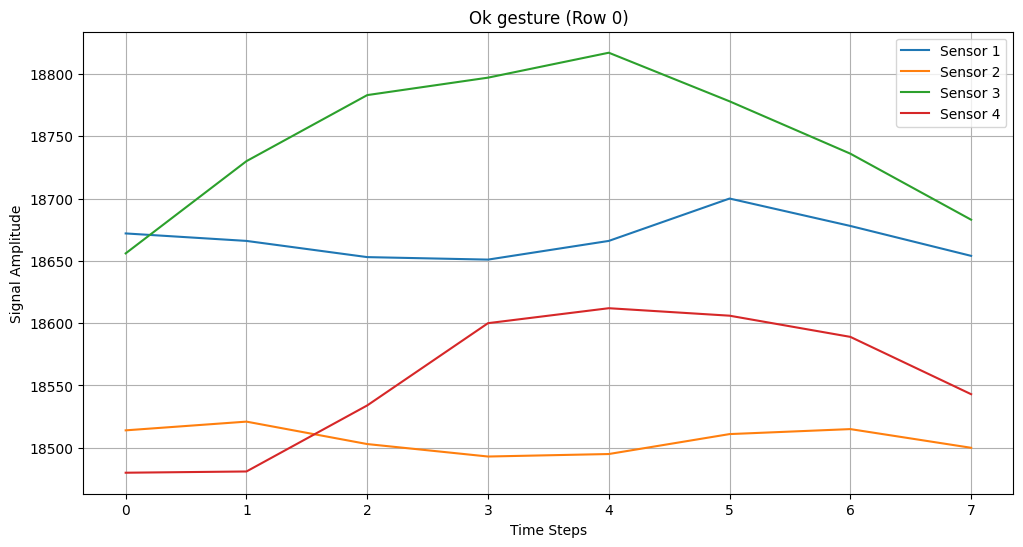

In [23]:
plot_time_signals(ok_df, row_index=0, title='Ok gesture')

In [24]:
if plot_all_timeline:
    plot_all_time_signals(neutral_df, title='Neutral gesture: whole timeline')
    plot_all_time_signals(fist_df, title='Fist gesture: whole timeline')
    plot_all_time_signals(peace_df, title='Peace gesture: whole timeline')
    plot_all_time_signals(ok_df, title='Ok gesture: whole timeline')
    plot_all_time_signals(index_df, title='Index gesture: whole timeline')
    plot_all_time_signals(middle_df, title='Middle gesture: whole timeline')

## Class distribution

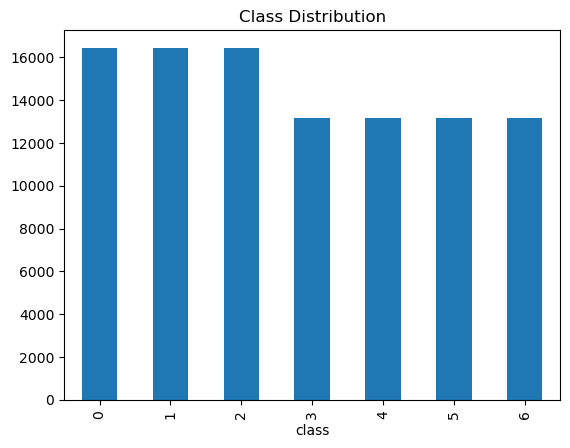

In [18]:
df.iloc[:, -1].value_counts().plot(kind='bar', title="Class Distribution")
plt.show()

## Sensor correlation analysis

/tmp/ipykernel_30242/515862046.py:1: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  sensor_means = sensor_data.groupby(np.arange(sensor_data.shape[1]) // 8, axis=1).mean()


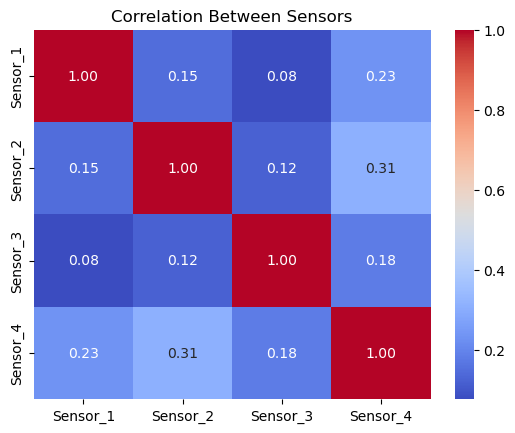

In [19]:
sensor_means = sensor_data.groupby(np.arange(sensor_data.shape[1]) // 8, axis=1).mean()

sensor_means.columns = [f"Sensor_{i+1}" for i in range(4)]

correlation = sensor_means.corr()

sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Between Sensors")
plt.show()

In [89]:
from scipy import signal
from scipy.signal import butter
from numpy import mean, std

lf = 20
hf = 400
fs = 1150
trim = 4*8*100
bandpass_order = 3
outlier_rejection_stds = 6

def _remove_outliers(data):
    data_mean, data_std = mean(data.flatten()), std(data.flatten())
    cut_off = data_std * outlier_rejection_stds
    lower, upper = data_mean - cut_off, data_mean + cut_off

    outliers_removed = [x if x >= lower and x <= upper else 0.0 for x in data]
    return outliers_removed

def _remove_artefact(data):
    data[:trim] = 0
    return data

def preprocess_data(data):
    sos = butter(bandpass_order, (lf, hf), btype="bandpass", fs=fs, output="sos")
    proc_data = signal.sosfilt(sos, data) # f
    proc_data = _remove_artefact(proc_data)
    return proc_data


## Dimensionality Reduction

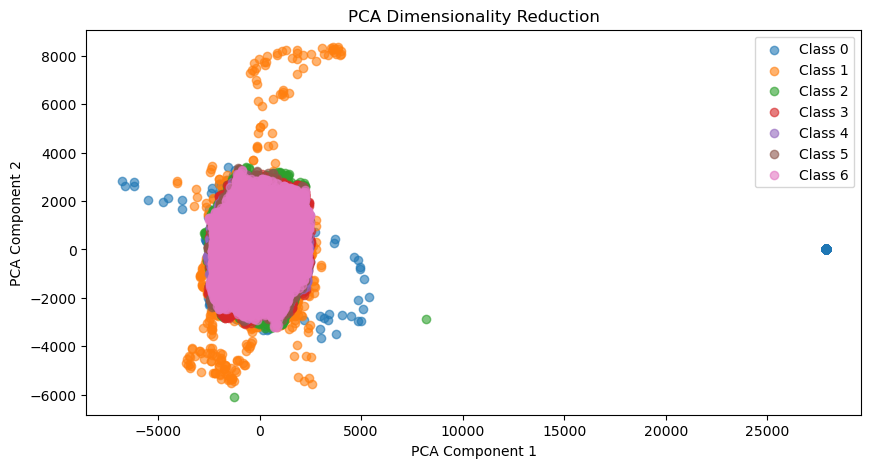

In [21]:
# PCA Dimensionality Reduction to 2 components
pca = PCA(n_components=2)
sensor_preproc = preprocess_data(sensor_data)
pca_result = pca.fit_transform(sensor_preproc)

# Plot PCA results
plt.figure(figsize=(10, 5))
for class_id in np.unique(labels):
    plt.scatter(pca_result[labels == class_id, 0], pca_result[labels == class_id, 1], label=f'Class {class_id}', alpha=0.6)
plt.title("PCA Dimensionality Reduction")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend()
plt.show()

# # t-SNE Dimensionality Reduction to 2 components
# tsne = TSNE(n_components=2, perplexity=30, random_state=42)
# tsne_result = tsne.fit_transform(sensor_preproc)

# # Plot t-SNE results
# plt.figure(figsize=(10, 5))
# for class_id in np.unique(labels):
#     plt.scatter(tsne_result[labels == class_id, 0], tsne_result[labels == class_id, 1], label=f'Class {class_id}', alpha=0.6)
# plt.title("t-SNE Dimensionality Reduction")
# plt.xlabel("t-SNE Component 1")
# plt.ylabel("t-SNE Component 2")
# plt.legend()
# plt.show()

## Data Preprocessing

## Spectal Analysis

In [22]:
preprocess = True

def spectral_analysis_overall(dataframe):
    time_steps_per_sensor = dataframe.shape[1] // num_sensors

    # Separate gesture class and sensor data
    gesture_classes = dataframe.iloc[:, -1]
    sensor_data = dataframe.iloc[:, :-1]
    
    # Prepare to store FFT results for each sensor
    fft_results = {f'Sensor_{i+1}': [] for i in range(num_sensors)}

    # Loop over all rows and accumulate FFT results per sensor
    for index, row in sensor_data.iterrows():
        signals = np.array_split(row.values, num_sensors)
        for i, signal in enumerate(signals):
            if preprocess:
                signal = preprocess_data(signal)
            fft_result = np.abs(fft(signal))[:time_steps_per_sensor // 2]  # Positive frequencies only
            fft_results[f'Sensor_{i+1}'].append(fft_result)
    
    # Compute average FFT amplitude for each sensor
    avg_fft_results = {sensor: np.mean(fft_results[sensor], axis=0) for sensor in fft_results}

    # Plot average FFT for each sensor
    plt.figure(figsize=(15, 10))
    for sensor, avg_fft in avg_fft_results.items():
        freqs = fftfreq(time_steps_per_sensor, d=1/fs)[:time_steps_per_sensor // 2]  # Positive frequencies
        plt.plot(freqs, avg_fft, label=sensor)
    
    plt.title("Average Spectral Analysis for All Sensors")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Now analyze by gesture class
    unique_classes = np.unique(gesture_classes)
    plt.figure(figsize=(15, 10))
    for gesture_class in unique_classes:
        class_subset = dataframe[dataframe.iloc[:, -1] == gesture_class]
        class_fft_results = {f'Sensor_{i+1}': [] for i in range(num_sensors)}
        for _, row in class_subset.iloc[:, :-1].iterrows():
            signals = np.array_split(row.values, num_sensors)
            for i, signal in enumerate(signals):
                if preprocess:
                    signal = preprocess_data(signal)
                fft_result = np.abs(fft(signal))[:time_steps_per_sensor // 2]
                class_fft_results[f'Sensor_{i+1}'].append(fft_result)
        # Average across this class
        avg_class_fft = np.mean([np.mean(class_fft_results[sensor], axis=0) for sensor in class_fft_results], axis=0)
        freqs = fftfreq(time_steps_per_sensor, d=1/fs)[:time_steps_per_sensor // 2]
        plt.plot(freqs, avg_class_fft, label=f"Class {gesture_class}")

    plt.title("Average Spectral Analysis by Gesture Class")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.grid(True)
    plt.show()

In [30]:
spectral_analysis_overall(df)

KeyboardInterrupt: 

## Train networks

In [90]:
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

In [91]:
import neurokit2 as nk

def transform_features(X, feature='EMG_Amplitude'):
    for sensor in range(num_sensors):
        signals, info = nk.emg_process(X[sensor, :], sampling_rate=fs)
        nk.emg_plot(signals, info)
        X[sensor, :] = signals[feature].values

In [92]:
X = preprocess_data(X)

In [93]:
X.max(), X.min()

(18885.416724852214, -9284.468564922892)

In [ ]:
from sklearn.preprocessing import RobustScaler
# scaler= RobustScaler()
scaler = StandardScaler()

X = scaler.fit_transform(X)

(4, 815920)


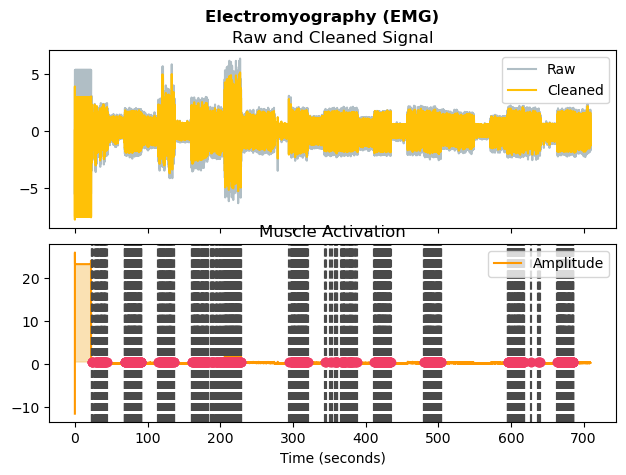

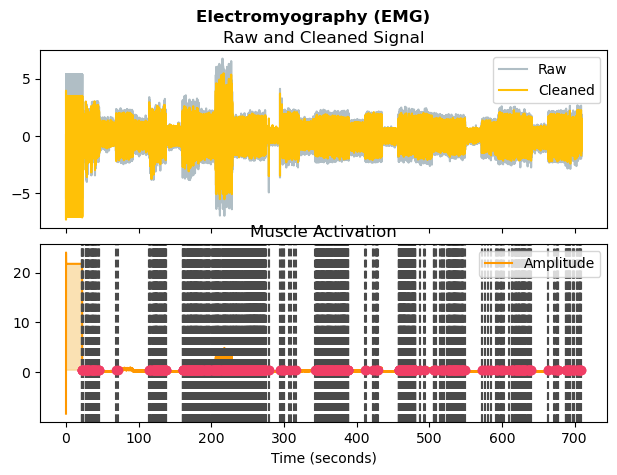

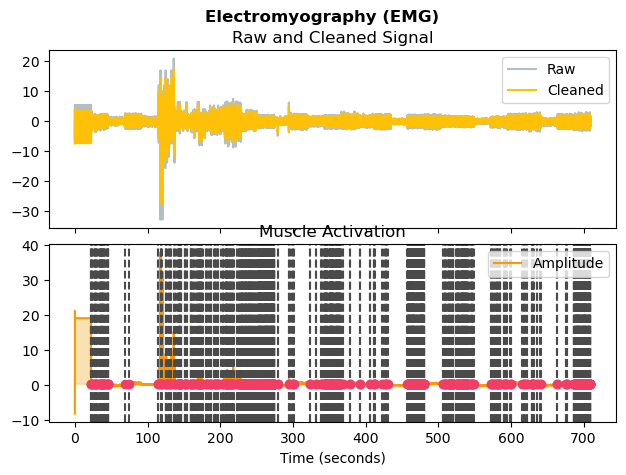

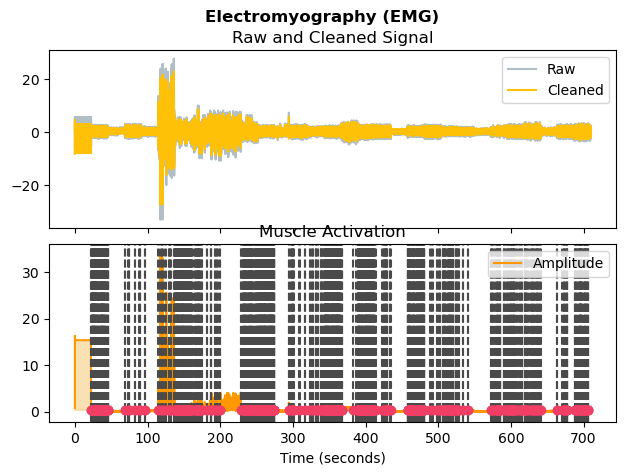

In [ ]:
x_shape = X.shape
X = X.reshape(-1, 4)
# swap rows and columns
X = X.T
print(X.shape)
transform_features(X)
X = X.T
X = X.reshape(x_shape)

In [52]:
from pickle import dump
with open("custom_scaler_transformed_features.pkl", "wb") as f:
    dump(scaler, f, protocol=5)

In [53]:
X.max(), X.min()

(215.52462632894122, -94.85854405562193)

In [54]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=42)

In [55]:
# Count classes in y_test
unique, counts = np.unique(y_test, return_counts=True)
unique, counts

(array([0, 1, 2, 3, 4, 5, 6]),
 array([3314, 3264, 3373, 2654, 2684, 2544, 2565]))

## Classical models

In [56]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(n_estimators=100, max_features='sqrt', max_depth=100, min_impurity_decrease=0.00005, random_state=42)
clf.fit(X_train, y_train)

RandomForestClassifier(max_depth=100, min_impurity_decrease=5e-05,
                       random_state=42)

In [57]:
depths = [estimator.get_depth() for estimator in clf.estimators_]
min(depths), max(depths)

(26, 35)

In [58]:
from pickle import dump
with open("custom_classifier_transformed_features.pkl", "wb") as f:
    dump(clf, f, protocol=5)

In [59]:
y_pred = clf.predict(X_train)
print('Classification Report: \n', classification_report(y_train, y_pred))
print('Confusion Matrix: \n', confusion_matrix(y_train, y_pred))

Classification Report: 
               precision    recall  f1-score   support

           0       0.55      0.83      0.66     13136
           1       0.86      0.86      0.86     13186
           2       0.72      0.52      0.60     13077
           3       0.63      0.62      0.63     10506
           4       0.70      0.53      0.61     10476
           5       0.64      0.61      0.62     10616
           6       0.61      0.62      0.62     10595

    accuracy                           0.66     81592
   macro avg       0.67      0.66      0.66     81592
weighted avg       0.68      0.66      0.66     81592

Confusion Matrix: 
 [[10911    75   416   478   307   559   390]
 [  350 11291   248   598   142    64   493]
 [ 2272   757  6767   716   558  1182   825]
 [ 1466   567   453  6543   329   371   777]
 [ 1564   131   504   708  5595   995   979]
 [ 1759   111   445   547   580  6482   692]
 [ 1479   236   560   717   488   503  6612]]


In [60]:
y_pred = clf.predict(X_test)

In [61]:
print('Classification Report: \n', classification_report(y_test,y_pred))
print('Confusion Matrix: \n', confusion_matrix(y_test,y_pred))

Classification Report: 
               precision    recall  f1-score   support

           0       0.43      0.68      0.52      3314
           1       0.78      0.78      0.78      3264
           2       0.39      0.25      0.30      3373
           3       0.39      0.38      0.39      2654
           4       0.41      0.29      0.34      2684
           5       0.42      0.42      0.42      2544
           6       0.37      0.39      0.38      2565

    accuracy                           0.47     20398
   macro avg       0.46      0.46      0.45     20398
weighted avg       0.46      0.47      0.46     20398

Confusion Matrix: 
 [[2245   32  265  219  149  220  184]
 [  99 2561  120  253   45   32  154]
 [ 812  267  841  352  249  476  376]
 [ 523  249  254 1007  176  134  311]
 [ 544   40  219  292  778  419  392]
 [ 554   32  208  144  270 1067  269]
 [ 494  116  248  283  214  213  997]]


In [37]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

lr_grid = {'max_depth' : [4, 8, 16, 32, 64, 128],
           'criterion' : ['entropy', 'gini']}

clf = RandomForestClassifier(n_estimators=100, max_features='sqrt', random_state=42)

gs = GridSearchCV(estimator=clf, param_grid=lr_grid, cv=5)
gs.fit(X_train, y_train)
y_pred = gs.predict(X_test)

In [38]:
print('Classification Report: \n', classification_report(y_test,y_pred))
print('Confusion Matrix: \n', confusion_matrix(y_test,y_pred))

Classification Report: 
               precision    recall  f1-score   support

           0       0.90      0.95      0.92      6518
           1       0.97      0.94      0.96      6522
           2       0.94      0.94      0.94      6493
           3       0.95      0.95      0.95      5206
           4       0.95      0.95      0.95      5236
           5       0.95      0.94      0.94      5380
           6       0.96      0.93      0.94      5237

    accuracy                           0.94     40592
   macro avg       0.95      0.94      0.94     40592
weighted avg       0.94      0.94      0.94     40592

Confusion Matrix: 
 [[6198   22  113   65   23   75   22]
 [  90 6138   73   56   50   38   77]
 [ 180   35 6128   40   41   36   33]
 [  88   36   44 4966   25   26   21]
 [  91   12   52   34 4961   58   28]
 [ 144   15   45   30   66 5052   28]
 [ 105   56   62   52   38   49 4875]]


In [39]:
from pickle import dump
with open("custom_classifier_gen2.pkl", "wb") as f:
    dump(gs, f, protocol=5)

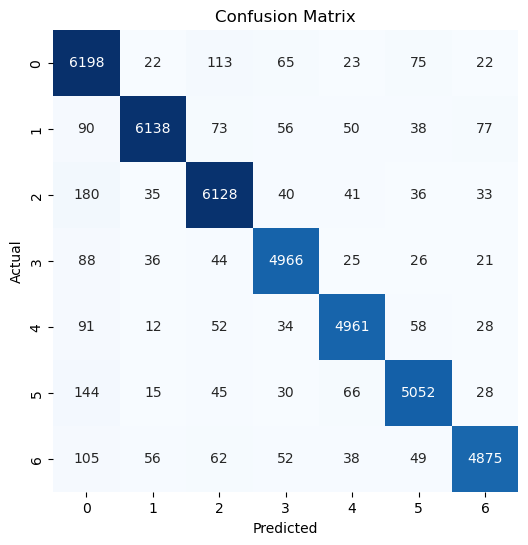

In [40]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', cbar=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## Deep Learning

In [62]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

In [63]:
class NeuralNet(nn.Module):
    def __init__(self, input_size, output_size):
        super(NeuralNet, self).__init__()
        self.fc1 = nn.Linear(input_size, 1024)
        self.dropout1 = nn.Dropout(0.2)
        self.fc2 = nn.Linear(1024, 1024)
        self.dropout2 = nn.Dropout(0.2)
        self.fc3 = nn.Linear(1024, output_size)
    
    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.dropout1(x)
        x = torch.relu(self.fc2(x))
        x = self.dropout2(x)
        x = torch.softmax(self.fc3(x), dim=1)
        return x

In [64]:
input_size = X_train.shape[1]
output_size = 7
batch_size = 64
epochs = 200
learning_rate = 0.001

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

ff_model = NeuralNet(input_size, output_size)
criterion = nn.CrossEntropyLoss()  # Sparse categorical cross-entropy
optimizer = optim.Adam(ff_model.parameters(), lr=learning_rate)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
ff_model.to(device)

NeuralNet(
  (fc1): Linear(in_features=32, out_features=1024, bias=True)
  (dropout1): Dropout(p=0.2, inplace=False)
  (fc2): Linear(in_features=1024, out_features=1024, bias=True)
  (dropout2): Dropout(p=0.2, inplace=False)
  (fc3): Linear(in_features=1024, out_features=7, bias=True)
)

In [65]:
batch_size = 256

In [66]:
for epoch in range(epochs):
    ff_model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        # Zero gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = ff_model(inputs)
        loss = criterion(outputs, labels)

        # Backward pass and optimization
        loss.backward()
        optimizer.step()

        # Compute running loss and accuracy
        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    scheduler.step(running_loss / total)
    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_accuracy = correct / total * 100
    
    ff_model.eval()
    with torch.no_grad():
        X_test_tensor = X_test_tensor.to(device)
        y_test_tensor = y_test_tensor.to(device)
        outputs = ff_model(X_test_tensor)
        _, predicted = outputs.max(1)
        test_accuracy = predicted.eq(y_test_tensor).sum().item() / y_test_tensor.size(0) * 100
    
    print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.2f}%, Test Accuracy: {test_accuracy:.2f}%")

Epoch 1/200, Loss: 1.8022, Accuracy: 34.36%, Test Accuracy: 38.12%
Epoch 2/200, Loss: 1.7702, Accuracy: 37.84%, Test Accuracy: 40.37%
Epoch 3/200, Loss: 1.7595, Accuracy: 39.08%, Test Accuracy: 39.16%
Epoch 4/200, Loss: 1.7544, Accuracy: 39.50%, Test Accuracy: 40.51%
Epoch 5/200, Loss: 1.7503, Accuracy: 40.08%, Test Accuracy: 40.54%
Epoch 6/200, Loss: 1.7475, Accuracy: 40.42%, Test Accuracy: 40.97%
Epoch 7/200, Loss: 1.7476, Accuracy: 40.35%, Test Accuracy: 41.57%
Epoch 8/200, Loss: 1.7441, Accuracy: 40.72%, Test Accuracy: 41.18%
Epoch 9/200, Loss: 1.7425, Accuracy: 40.92%, Test Accuracy: 42.01%
Epoch 10/200, Loss: 1.7408, Accuracy: 41.13%, Test Accuracy: 42.37%
Epoch 11/200, Loss: 1.7411, Accuracy: 41.09%, Test Accuracy: 41.48%
Epoch 12/200, Loss: 1.7400, Accuracy: 41.11%, Test Accuracy: 42.57%
Epoch 13/200, Loss: 1.7378, Accuracy: 41.30%, Test Accuracy: 42.60%
Epoch 14/200, Loss: 1.7371, Accuracy: 41.46%, Test Accuracy: 42.80%
Epoch 15/200, Loss: 1.7361, Accuracy: 41.67%, Test Accura

KeyboardInterrupt: 

In [ ]:
torch.save(ff_model.state_dict(), 'custom_nn_transformed_features.pth')

In [129]:
ff_model.eval()
with torch.no_grad():
    X_test_tensor = X_test_tensor.to(device)
    y_test_tensor = y_test_tensor.to(device)
    outputs = ff_model(X_test_tensor)
    _, predicted = outputs.max(1)
    test_accuracy = predicted.eq(y_test_tensor).sum().item() / y_test_tensor.size(0) * 100

print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Accuracy: 62.04%


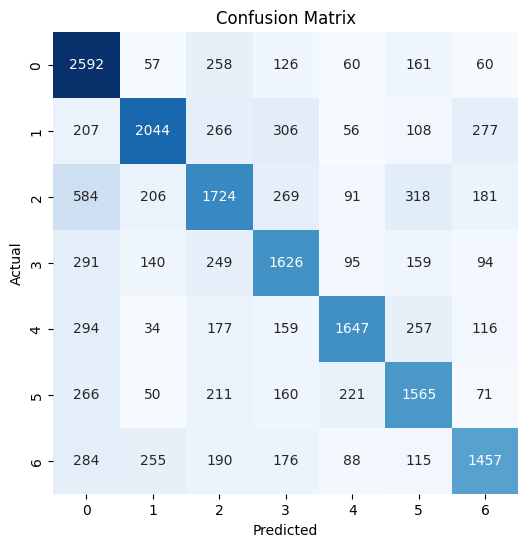

In [130]:
cm = confusion_matrix(y_test, predicted.cpu())

plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', cbar=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [112]:
import gc
gc.collect()

2461

In [67]:
class PureLSTM(nn.Module):
    
    def __init__(self, n_features, n_hidden, n_sequence, n_layers, n_classes):
        super(PureLSTM, self).__init__()
        
        self.n_features = n_features
        self.n_hidden = n_hidden
        self.n_sequence = n_sequence
        self.n_layers = n_layers
        self.n_classes = n_classes
        
        self.lstm = nn.LSTM(input_size=n_features, hidden_size=n_hidden, num_layers=n_layers, batch_first=True)
        
        self.linear_1 = nn.Linear(in_features=n_hidden, out_features=128)
        self.dropout_1 = nn.Dropout(p=0.2)
        
        self.linear_2 = nn.Linear(in_features=128, out_features=n_classes)        
        
    
    def forward(self, x):
        
        self.hidden = (
            torch.zeros(self.n_layers, x.shape[0], self.n_hidden).to(device),
            torch.zeros(self.n_layers, x.shape[0], self.n_hidden).to(device)
        )
    
        out, (hs, cs) = self.lstm(x.view(len(x), self.n_sequence, -1),self.hidden)
        out = out[:,-1,:]

        out = self.linear_1(out)
        out = self.dropout_1(out)
        out = self.linear_2(out)
        
        return out
    
def train_model(model, train_dataloader, n_epochs):
    global X_test_tensor, y_test_tensor
    
    running_loss = 0.0
    correct = 0
    total = 0
    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer)
    
    for epoch in range(n_epochs):
        model.train()
        for i, (inputs, labels) in enumerate(train_dataloader):
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            
            loss = loss_fn(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Compute running loss and accuracy
            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        scheduler.step(running_loss / total)
        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_accuracy = correct / total * 100
        
        model.eval()
        with torch.no_grad():
            X_test_tensor = X_test_tensor.to(device)
            y_test_tensor = y_test_tensor.to(device)
            outputs = model(X_test_tensor)
            _, predicted = outputs.max(1)
            test_accuracy = predicted.eq(y_test_tensor).sum().item() / y_test_tensor.size(0) * 100

        print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.2f}%, Test Accuracy: {test_accuracy:.2f}%")
        
    return model

In [68]:
n_features = 32
n_sequence=1
# n_features = 4
# n_sequence=8
n_hidden=32*3
n_layers=2
epochs = 400

model = PureLSTM(n_features, n_hidden, n_sequence, n_layers, output_size).to(device)

print("Train Data Shape ",X_train.shape, y_train.shape)
print("Test Data Shape ",X_test.shape, y_test.shape)

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)
# X_train_tensor = X_train_tensor.view(-1, n_sequence, n_features)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
model = train_model(model, train_loader, n_epochs = epochs)

Train Data Shape  (81592, 32) (81592,)
Test Data Shape  (20398, 32) (20398,)
Epoch 1/400, Loss: 1.7209, Accuracy: 28.44%, Test Accuracy: 33.22%
Epoch 2/400, Loss: 3.3253, Accuracy: 31.42%, Test Accuracy: 35.48%
Epoch 3/400, Loss: 4.8754, Accuracy: 33.18%, Test Accuracy: 38.67%
Epoch 4/400, Loss: 6.3889, Accuracy: 34.50%, Test Accuracy: 38.45%
Epoch 5/400, Loss: 7.8825, Accuracy: 35.43%, Test Accuracy: 39.17%
Epoch 6/400, Loss: 9.3681, Accuracy: 36.11%, Test Accuracy: 39.65%
Epoch 7/400, Loss: 10.8449, Accuracy: 36.65%, Test Accuracy: 39.92%
Epoch 8/400, Loss: 12.3112, Accuracy: 37.10%, Test Accuracy: 40.33%
Epoch 9/400, Loss: 13.7670, Accuracy: 37.53%, Test Accuracy: 41.71%
Epoch 10/400, Loss: 15.2101, Accuracy: 37.94%, Test Accuracy: 41.89%
Epoch 11/400, Loss: 16.6457, Accuracy: 38.31%, Test Accuracy: 42.43%
Epoch 12/400, Loss: 18.0767, Accuracy: 38.62%, Test Accuracy: 41.74%
Epoch 13/400, Loss: 19.5029, Accuracy: 38.90%, Test Accuracy: 42.65%
Epoch 14/400, Loss: 20.9236, Accuracy: 39

KeyboardInterrupt: 

In [ ]:
torch.save(model.state_dict(), 'custom_lstm_transformed_features.pth')

def evaluateModel(outputs, y):
    _, predicted = outputs.max(1)
    test_accuracy = predicted.eq(y).sum().item() / y.size(0) * 100
    return test_accuracy, predicted

model.eval()
with torch.no_grad():
    X_test_tensor = X_test_tensor.to(device)
    y_test_tensor = y_test_tensor.to(device)
    y_hat_test = model(X_test_tensor)
    acc, predicted = evaluateModel(y_hat_test, y_test_tensor)
    print(f"Test Accuracy: {acc:.2f}%")

Test Accuracy: 64.06%


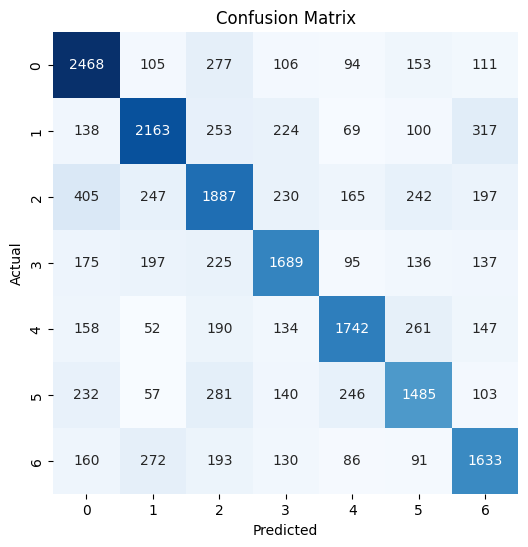

In [121]:
cm = confusion_matrix(y_test, predicted.cpu())

plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', cbar=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## Feature engineering